In [5]:
# ==========================================
# 1. Bibliotecas
# ==========================================

import os

import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# ==========================================
# 2. Caminho das imagens
# ==========================================

PASTA_IMAGENS = "../data/raw/images"

In [7]:
# ==========================================
# 3. Funções auxiliares
# ==========================================

def normalizar(img):
    img = img.astype(np.float32)

    minimo = np.nanpercentile(img, 2)
    maximo = np.nanpercentile(img, 98)

    img = np.clip(
        img,
        minimo,
        maximo
    )

    return (
        (img - minimo)
        / (maximo - minimo + 1e-8)
    )


def normalizar_conjunta(lista_bandas):
    empilhada = np.stack(
        lista_bandas,
        axis=0
    ).astype(np.float32)

    minimo = np.nanpercentile(
        empilhada,
        2
    )

    maximo = np.nanpercentile(
        empilhada,
        98
    )

    empilhada = np.clip(
        empilhada,
        minimo,
        maximo
    )

    empilhada = (
        (empilhada - minimo)
        / (maximo - minimo + 1e-8)
    )

    return np.dstack([
        empilhada[0],
        empilhada[1],
        empilhada[2]
    ])


def calcular_indice(a, b):
    a = a.astype(np.float32)
    b = b.astype(np.float32)

    denominador = a + b

    return np.divide(
        a - b,
        denominador,
        out=np.zeros_like(
            a,
            dtype=np.float32
        ),
        where=np.abs(denominador) > 1e-6
    )

In [8]:
# ==========================================
# 4. Abrir imagem
# ==========================================

def abrir_imagem(caminho):

    with rasterio.open(caminho) as src:

        bandas = {
            "B02": src.read(1),
            "B03": src.read(2),
            "B04": src.read(3),
            "B08": src.read(4),
            "B11": src.read(5),
            "B12": src.read(6)
        }

    return bandas

In [9]:
# ==========================================
# 5. Visualização
# ==========================================

def mostrar_imagem(bandas, titulo=""):

    rgb_natural = normalizar_conjunta([
        bandas["B04"],
        bandas["B03"],
        bandas["B02"]
    ])

    rgb_contrastado = np.dstack([
        normalizar(bandas["B04"]),
        normalizar(bandas["B03"]),
        normalizar(bandas["B02"])
    ])

    falsa_cor_nir = np.dstack([
        normalizar(bandas["B08"]),
        normalizar(bandas["B04"]),
        normalizar(bandas["B03"])
    ])

    composicao_swir = np.dstack([
        normalizar(bandas["B11"]),
        normalizar(bandas["B08"]),
        normalizar(bandas["B04"])
    ])

    ndwi = calcular_indice(
        bandas["B03"],
        bandas["B08"]
    )

    mndwi = calcular_indice(
        bandas["B03"],
        bandas["B11"]
    )

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(18, 12)
    )

    axes[0, 0].imshow(rgb_natural)
    axes[0, 0].set_title("RGB natural")

    axes[0, 1].imshow(rgb_contrastado)
    axes[0, 1].set_title("RGB contrastado")

    axes[0, 2].imshow(falsa_cor_nir)
    axes[0, 2].set_title("Falsa cor — NIR")

    axes[1, 0].imshow(composicao_swir)
    axes[1, 0].set_title("Composição SWIR")

    imagem_ndwi = axes[1, 1].imshow(
        ndwi,
        cmap="BrBG",
        vmin=-1,
        vmax=1
    )

    axes[1, 1].set_title("NDWI")

    fig.colorbar(
        imagem_ndwi,
        ax=axes[1, 1],
        fraction=0.046,
        pad=0.04
    )

    imagem_mndwi = axes[1, 2].imshow(
        mndwi,
        cmap="BrBG",
        vmin=-1,
        vmax=1
    )

    axes[1, 2].set_title("MNDWI")

    fig.colorbar(
        imagem_mndwi,
        ax=axes[1, 2],
        fraction=0.046,
        pad=0.04
    )

    for eixo in axes.ravel():
        eixo.axis("off")

    if titulo:
        fig.suptitle(
            titulo,
            fontsize=18,
            y=0.98
        )

    plt.tight_layout(
        rect=[0, 0, 1, 0.96]
    )

    plt.show()

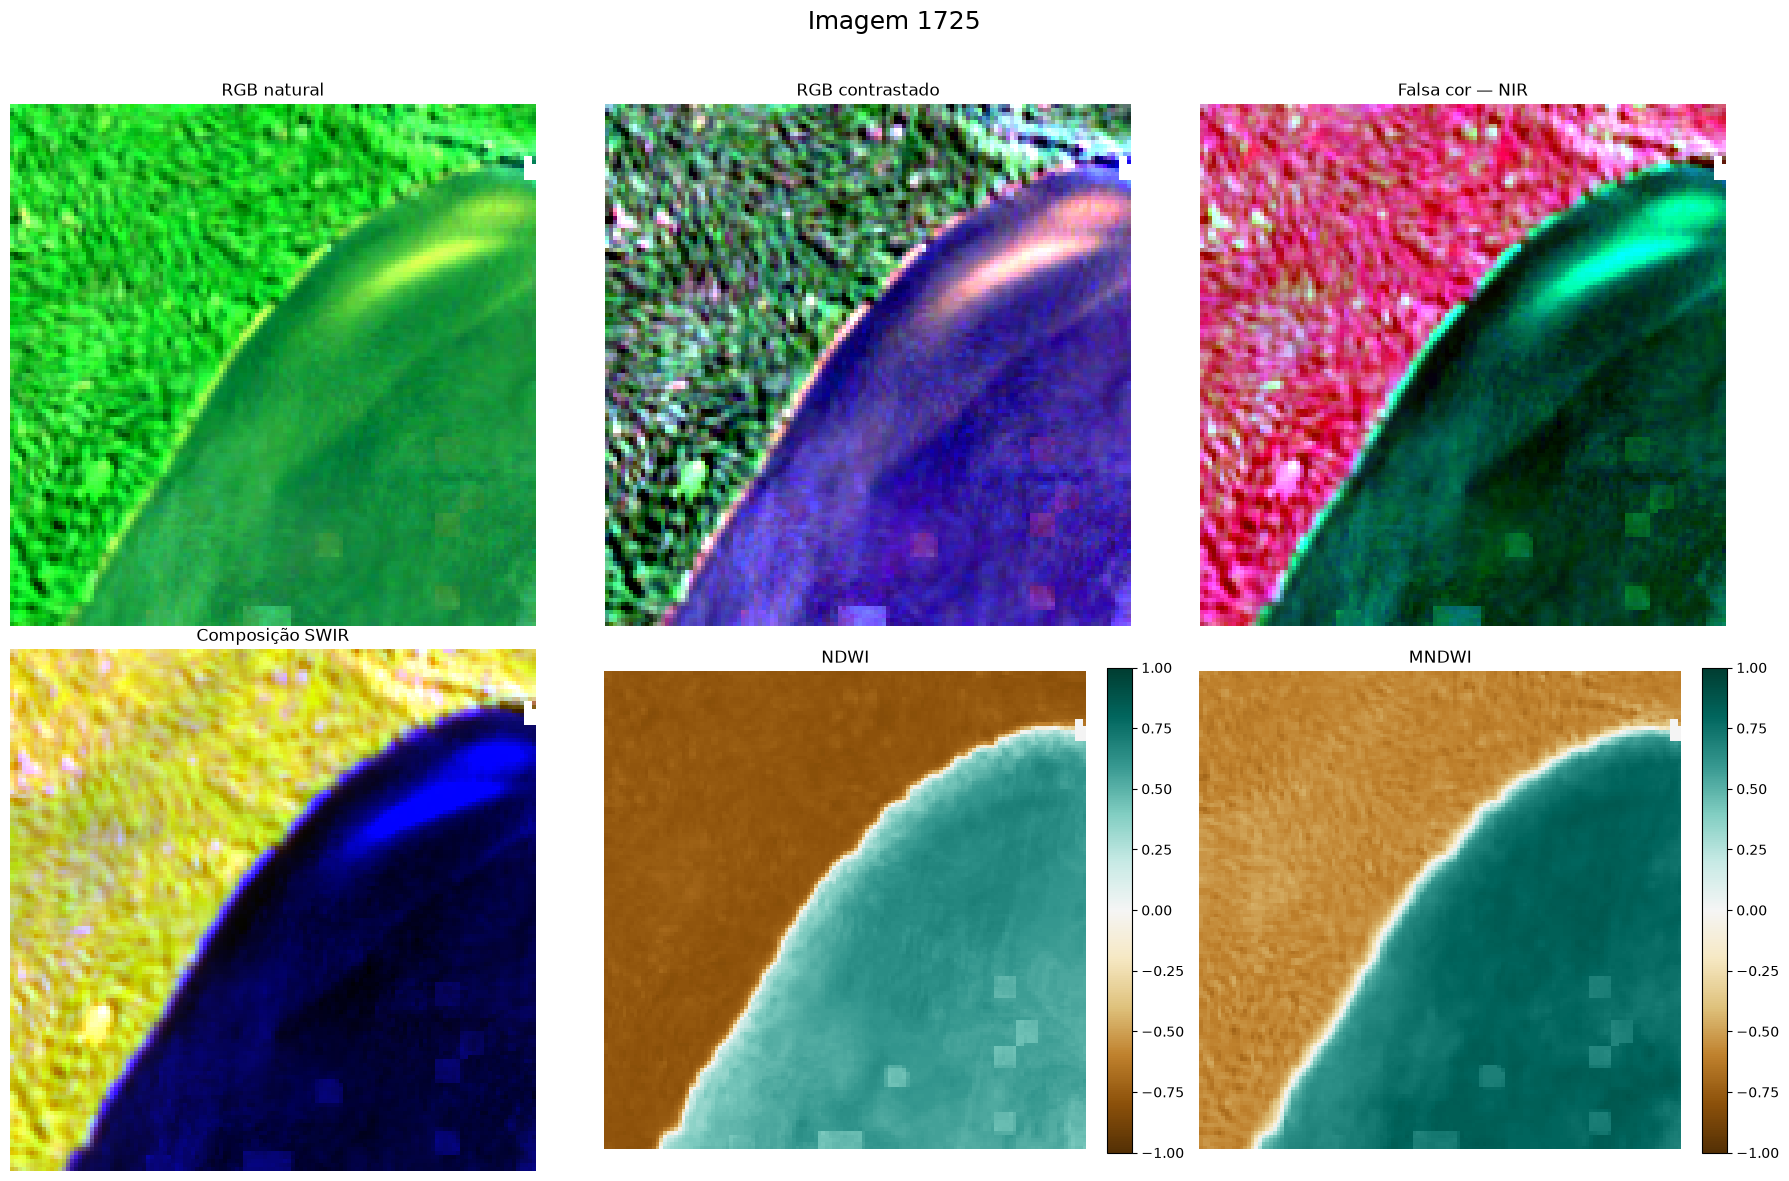

In [10]:
ID_IMAGEM = 1725


caminho_imagem = os.path.join(
    # PASTA_IMAGENS,
    "../data/raw/images/"
    f"{ID_IMAGEM}.tif"
)

bandas = abrir_imagem(
    caminho_imagem
)

mostrar_imagem(
    bandas,
    titulo=f"Imagem {ID_IMAGEM}"
)

## Leitura de várias

In [11]:
import os
import glob

import numpy as np
import rasterio
import matplotlib.pyplot as plt

In [12]:
PASTA_IMAGENS = "../data/segmentacao/images"
PASTA_MASCARAS = "../data/segmentacao/masks_final"

In [13]:
def normalizar(img):
    img = img.astype(np.float32)

    minimo = np.nanpercentile(img, 2)
    maximo = np.nanpercentile(img, 98)

    img = np.clip(
        img,
        minimo,
        maximo
    )

    return (
        (img - minimo)
        / (maximo - minimo + 1e-8)
    )


def carregar_rgb(caminho_imagem):

    with rasterio.open(caminho_imagem) as src:
        b02 = src.read(1)
        b03 = src.read(2)
        b04 = src.read(3)

    rgb = np.dstack([
        normalizar(b04),
        normalizar(b03),
        normalizar(b02)
    ])

    return rgb

In [14]:
def visualizar_mascaras(
    ids,
    pasta_imagens=PASTA_IMAGENS,
    pasta_mascaras=PASTA_MASCARAS
):

    quantidade = len(ids)

    fig, axes = plt.subplots(
        quantidade,
        3,
        figsize=(15, 5 * quantidade)
    )

    if quantidade == 1:
        axes = np.array([axes])

    for linha, id_imagem in enumerate(ids):

        id_imagem = str(id_imagem)

        caminho_imagem = os.path.join(
            pasta_imagens,
            f"{id_imagem}.tif"
        )

        caminho_mascara = os.path.join(
            pasta_mascaras,
            f"{id_imagem}.tif"
        )

        if not os.path.exists(caminho_imagem):
            print(
                f"Imagem não encontrada: "
                f"{caminho_imagem}"
            )
            continue

        if not os.path.exists(caminho_mascara):
            print(
                f"Máscara não encontrada: "
                f"{caminho_mascara}"
            )
            continue

        rgb = carregar_rgb(
            caminho_imagem
        )

        with rasterio.open(
            caminho_mascara
        ) as src:

            mascara = src.read(1)

        # -------------------------
        # RGB
        # -------------------------

        axes[linha, 0].imshow(rgb)

        axes[linha, 0].set_title(
            f"{id_imagem} — RGB"
        )

        # -------------------------
        # Máscara
        # -------------------------

        axes[linha, 1].imshow(
            mascara,
            cmap="gray",
            vmin=0,
            vmax=255
        )

        axes[linha, 1].set_title(
            "Ground truth"
        )

        # -------------------------
        # Sobreposição
        # -------------------------

        axes[linha, 2].imshow(
            rgb
        )

        axes[linha, 2].imshow(
            mascara,
            cmap="Reds",
            alpha=0.45,
            vmin=0,
            vmax=255
        )

        axes[linha, 2].set_title(
            "Sobreposição"
        )

        for coluna in range(3):
            axes[linha, coluna].axis(
                "off"
            )

    plt.tight_layout()
    plt.show()

Imagem não encontrada: ../data/segmentacao/images/121439.tif
Imagem não encontrada: ../data/segmentacao/images/121878.tif
Imagem não encontrada: ../data/segmentacao/images/121884.tif
Imagem não encontrada: ../data/segmentacao/images/122329.tif
Imagem não encontrada: ../data/segmentacao/images/123654.tif
Imagem não encontrada: ../data/segmentacao/images/128538.tif
Imagem não encontrada: ../data/segmentacao/images/128944.tif
Imagem não encontrada: ../data/segmentacao/images/139610.tif
Imagem não encontrada: ../data/segmentacao/images/139617.tif


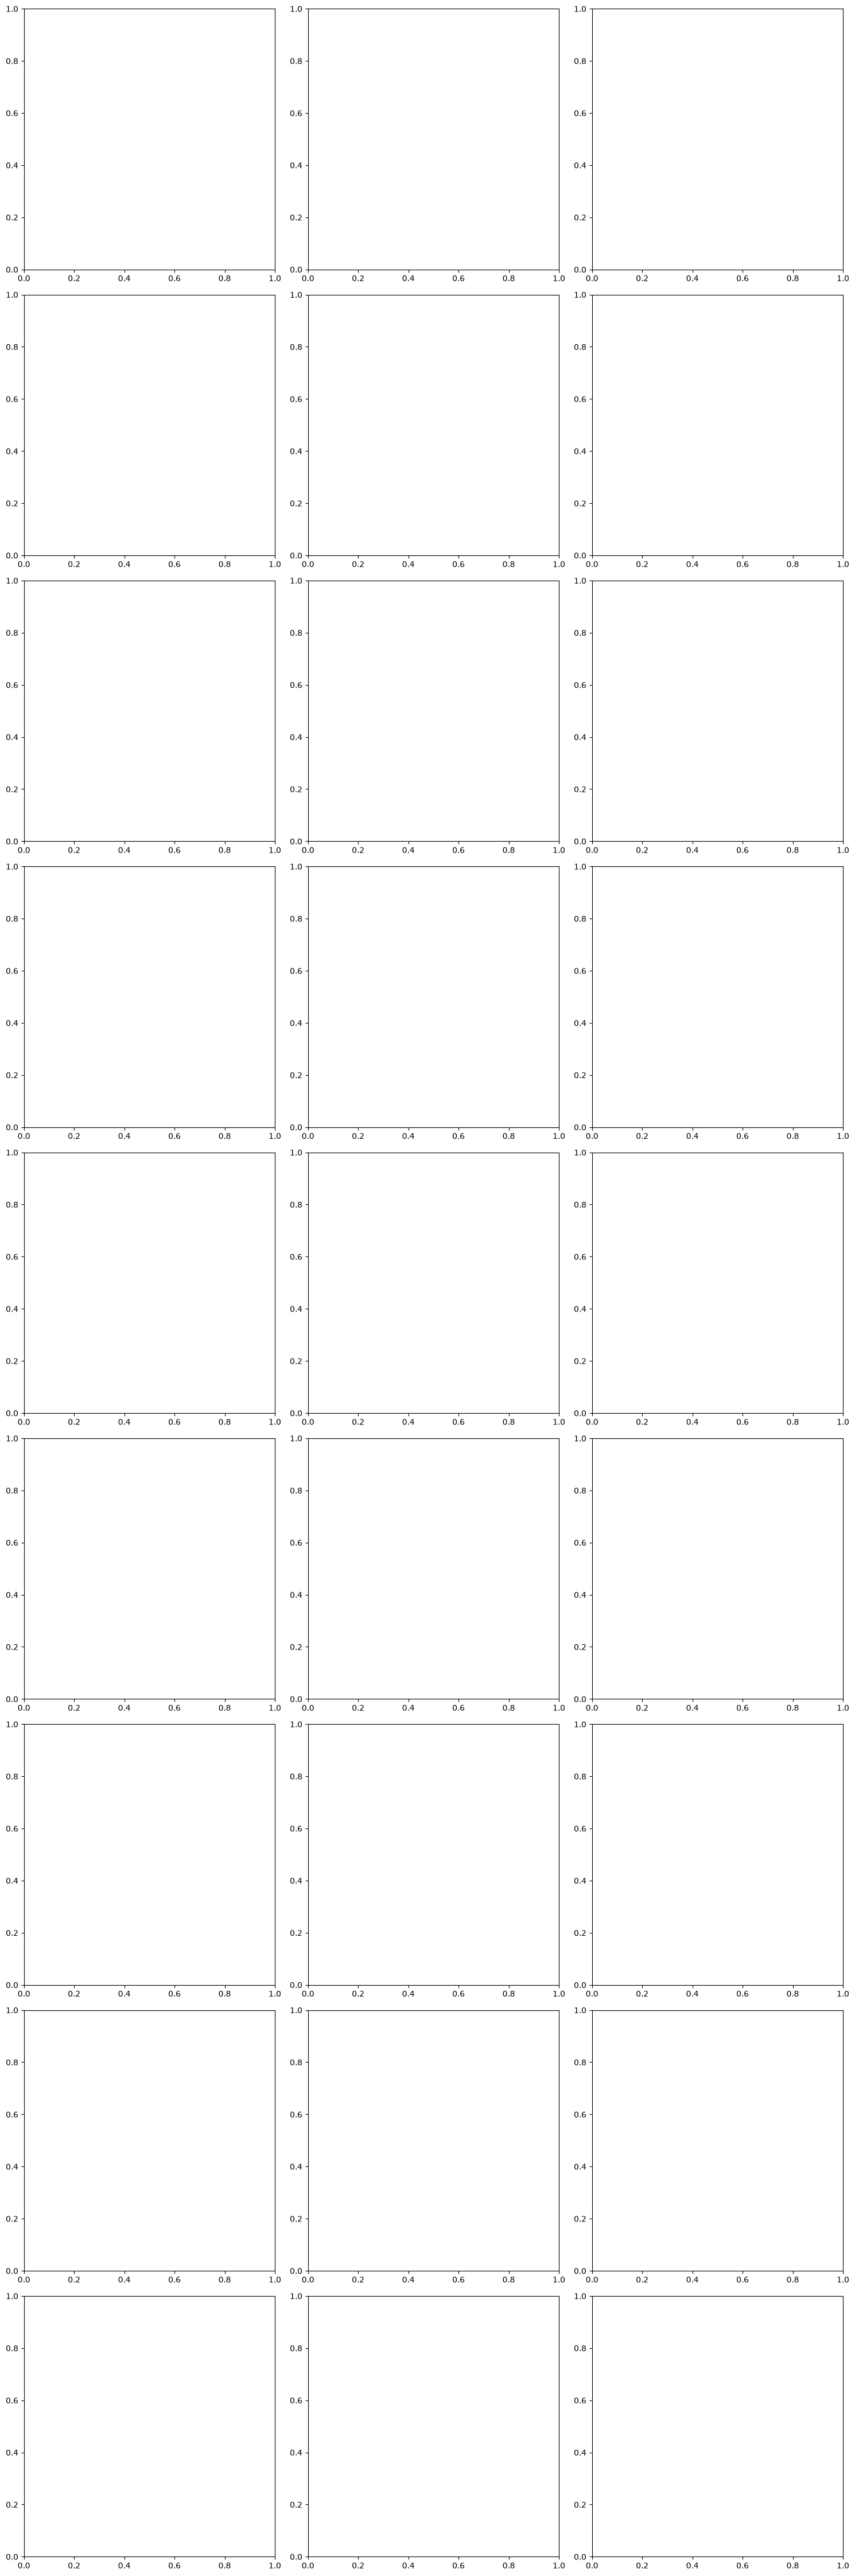

In [15]:
ids_para_ver = [
    121439,
    121878,
    121884,
    122329,
    123654,
    128538,
    128944,
    139610,
    139617
]

visualizar_mascaras(
    ids_para_ver
)